# Bilevel Planning in KinDER

Bilevel planning solves complex manipulation tasks in two layers:

1. **Abstract task planning** — a symbolic planner searches over STRIPS operators to
   find a sequence of high-level actions (e.g. *pick*, *place*) that achieves the goal.
2. **Continuous skill execution** — each abstract action is paired with a parameterized
   controller that generates low-level motor commands to carry it out.

This notebook walks through setting up an environment, inspecting the
planning models, running the planner, and visualizing the result.

In [1]:
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from PIL import Image as PILImage

import kinder
from kinder_bilevel_planning.agent import BilevelPlanningAgent
from kinder_bilevel_planning.env_models import create_bilevel_planning_models

## Setting Up the Environment

We use **Obstruction2D** with one obstruction — the robot must relocate the
obstacle before it can place the target block on the goal surface.

/Users/tom/prpl-mono/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:284: UserWarning: WARN: RGB-array rendering should return a numpy array in which the last axis has three dimensions, got 4
  logger.warn(


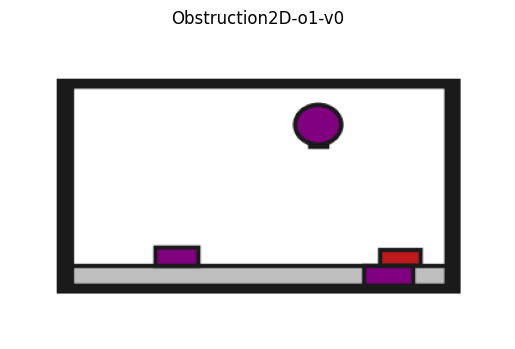

In [2]:
kinder.register_all_environments()

env = kinder.make("kinder/Obstruction2D-o1-v0", render_mode="rgb_array")
obs, info = env.reset(seed=123)

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("Obstruction2D-o1-v0")
plt.show()

## Creating the Bilevel Planning Models

The bilevel planning models define the abstract reasoning layer: object types,
symbolic predicates, STRIPS operators, and parameterized skills.

In [3]:
env_models = create_bilevel_planning_models(
    "obstruction2d",
    env.observation_space,
    env.action_space,
    num_obstructions=1,
)

## Predicates

Predicates are symbolic propositions that describe the current state
(e.g. *the robot is holding a block*, *a block is on the target surface*).

In [4]:
for predicate in sorted(env_models.predicates, key=str):
    print(predicate)

(HandEmpty ?x0 - crv_robot)
(Holding ?x0 - crv_robot ?x1 - rectangle)
(OnTable ?x0 - rectangle)
(OnTarget ?x0 - rectangle)


## Operators

Operators are lifted STRIPS actions. Each one declares typed parameters,
preconditions, and effects — defining how a skill changes the abstract state.

In [5]:
for operator in sorted(env_models.operators, key=lambda o: o.name):
    print(operator)
    print()

(:action PickFromTable
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (HandEmpty ?robot)
        (OnTable ?block))
    :effect (and (Holding ?robot ?block)
        (not (HandEmpty ?robot))
        (not (OnTable ?block)))
)

(:action PickFromTarget
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (HandEmpty ?robot)
        (OnTarget ?block))
    :effect (and (Holding ?robot ?block)
        (not (HandEmpty ?robot))
        (not (OnTarget ?block)))
)

(:action PlaceOnTable
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (Holding ?robot ?block))
    :effect (and (HandEmpty ?robot)
        (OnTable ?block)
        (not (Holding ?robot ?block)))
)

(:action PlaceOnTarget
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (Holding ?robot ?block))
    :effect (and (HandEmpty ?robot)
        (OnTarget ?block)
        (not (Holding ?robot ?block)))
)



## Skills

Each skill pairs an operator with a parameterized controller that generates
the low-level actions to execute it.

In [6]:
for skill in sorted(env_models.skills, key=lambda s: s.operator.name):
    print(f"{skill.operator.name:20s} -> {type(skill.controller).__name__}")

PickFromTable        -> LiftedParameterizedController
PickFromTarget       -> LiftedParameterizedController
PlaceOnTable         -> LiftedParameterizedController
PlaceOnTarget        -> LiftedParameterizedController


## Running the Planner

Calling `agent.reset()` triggers abstract planning (searching over operator
sequences) followed by trajectory sampling (finding continuous parameters
for each skill).

In [7]:
agent = BilevelPlanningAgent(
    env_models,
    seed=123,
    max_abstract_plans=10,
    samples_per_step=1,
)

obs, info = env.reset(seed=123)
agent.reset(obs, info)
print("Planning complete.")

Planning complete.


## Executing the Plan

The agent returns one low-level action per `step()` call. We feed it into the
environment and collect rendered frames.

In [8]:
frames = [env.render()]
total_reward = 0.0

for _ in range(1000):
    action = agent.step()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    agent.update(obs, reward, terminated or truncated, info)
    frames.append(env.render())
    if terminated or truncated:
        break

print(f"Done in {len(frames)} steps, total reward: {total_reward:.2f}")

Done in 129 steps, total reward: -128.00


## Visualizing the Result

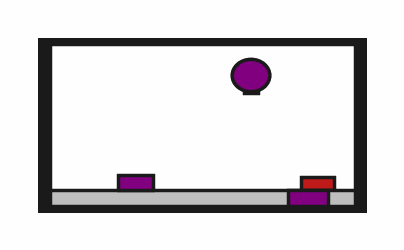

In [9]:
pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [10]:
env.close()